# Cell Type and Compartment Annotation for Xenium Human Ovarian Cancer

Hierarchical marker-based annotation with negative gating and spatial compartment definition for the 10x Xenium ovarian cancer dataset.

## Dataset

| | |
|:--|:--|
| **Source** | [10x Genomics — Xenium Prime 5K Human Ovarian Cancer](https://www.10xgenomics.com/datasets) |
| **Tissue** | FFPE Papillary Serous Carcinoma (Stage III-B) |
| **Panel** | Xenium Prime 5K (5,001 base + 100 custom = 5,101 genes) |
| **Cells** | 407,124 raw → 319,927 after QC → 265,387 after spatial crop |

## Pipeline

1. **Load** raw Xenium output → normalize (normalize_total + log1p)
2. **QC** — filter cells with <50 detected genes
3. **Spatial crop** — remove tissue edge artifacts (x<8000, y<6000 µm)
4. **Lineage assignment** — score each cell against canonical marker panels with negative gating
5. **Subtype refinement** — deterministic marker rules within each lineage
6. **Compartment definition** — epithelial density → signed distance transform → Tumor / Interface / Stroma
7. **Validation** — marker dot plot, proportions, spatial co-localization
8. **Save** clean h5ad for CONSTELLATION

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.sparse import issparse
from scipy.spatial import cKDTree
from scipy.ndimage import gaussian_filter, distance_transform_edt, binary_fill_holes
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

def get_expression(adata, gene):
    """Get expression array for a gene."""
    if gene not in adata.var_names:
        return np.zeros(adata.n_obs)
    X = adata[:, gene].X
    if issparse(X):
        X = X.toarray().flatten()
    return np.asarray(X).flatten()

def get_expr_fraction(adata, mask, gene):
    """Get fraction of cells expressing a gene."""
    if gene not in adata.var_names:
        return 0.0
    X = adata[mask, gene].X
    if issparse(X):
        X = X.toarray()
    return float((X > 0).mean())

In [2]:
# Paths
RAW_H5_PATH = 'data/cell_feature_matrix.h5'
CELLS_PATH = 'data/cells.csv.gz'
OUTPUT_PATH = 'data/xenium_oc_annotated.h5ad'

# QC
MIN_GENES = 50

# Spatial crop (remove edge artifacts)
X_MAX = 8000  # µm
Y_MAX = 6000  # µm

# Compartment parameters
GRID_SIZE = 10       # µm per grid pixel
SIGMA = 5            # smoothing = SIGMA * GRID_SIZE = 50 µm
EPI_THRESHOLD = 0.5  # epithelial fraction threshold
INTERFACE_WIDTH = 50 # µm

---
## 1. Load and Preprocess

Load raw Xenium output, add spatial coordinates, and apply standard scanpy normalization (normalize_total + log1p).

The input files are:
- `cell_feature_matrix.h5` — raw transcript count matrix
- `cells.csv.gz` — cell coordinates and metadata from Xenium

In [3]:
# Load raw count matrix
adata = sc.read_10x_h5(RAW_H5_PATH)
adata.var_names_make_unique()
print(f'Raw: {adata.n_obs:,} cells x {adata.n_vars:,} genes')

# Add spatial coordinates
cells = pd.read_csv(CELLS_PATH)
adata.obs['x_centroid'] = cells['x_centroid'].values
adata.obs['y_centroid'] = cells['y_centroid'].values
adata.obsm['spatial'] = cells[['x_centroid', 'y_centroid']].values

# Normalize
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Verify
print(f'Normalization: adata.uns["log1p"] = {adata.uns.get("log1p", "NOT FOUND")}')
if issparse(adata.X):
    sample = adata.X[:1000].toarray()
else:
    sample = np.asarray(adata.X[:1000])
print(f'Expression range: [{sample.min():.1f}, {sample.max():.1f}]')
print(f'Sparsity: {(sample == 0).mean()*100:.1f}%')

Raw: 407,124 cells x 5,101 genes


Normalization: adata.uns["log1p"] = {'base': None}
Expression range: [0.0, 7.6]
Sparsity: 93.4%


---
## 2. Quality Filtering and Spatial Crop

Remove low-quality cells (<50 genes detected) and crop to the main tissue area to avoid edge artifacts.

In [4]:
# QC: >=50 genes detected
genes_detected = np.array((adata.X > 0).sum(axis=1)).flatten()
print(f'Before QC: {adata.n_obs:,}')
print(f'Cells with <{MIN_GENES} genes: {(genes_detected < MIN_GENES).sum():,}')

adata = adata[genes_detected >= MIN_GENES].copy()
print(f'After QC: {adata.n_obs:,}')

# Spatial crop
x = adata.obs['x_centroid'].values
y = adata.obs['y_centroid'].values
in_crop = (x < X_MAX) & (y < Y_MAX)
print(f'\nBefore crop: {adata.n_obs:,}')
print(f'Outside crop region: {(~in_crop).sum():,}')

adata = adata[in_crop].copy()
print(f'After crop (x<{X_MAX}, y<{Y_MAX}): {adata.n_obs:,}')

Before QC: 407,124
Cells with <50 genes: 87,197


After QC: 319,927

Before crop: 319,927
Outside crop region: 54,540


After crop (x<8000, y<6000): 265,387


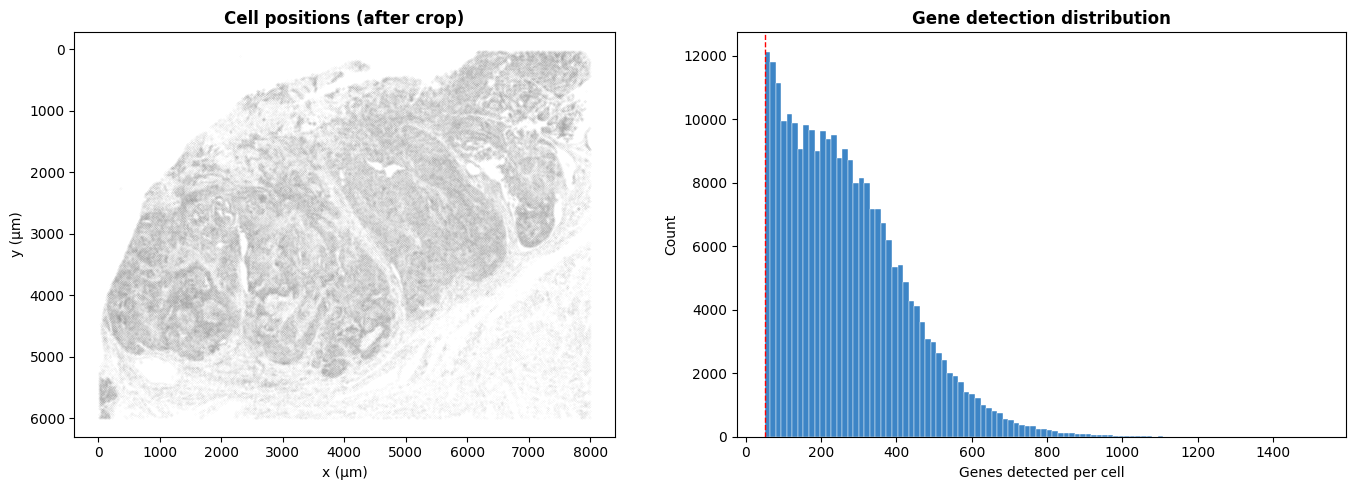

Spatial extent: x=[13, 8000] µm, y=[21, 6000] µm
Median genes/cell: 244


In [5]:
# Spatial overview
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = adata.obs['x_centroid'].values
y = adata.obs['y_centroid'].values

ax = axes[0]
ax.scatter(x, y, s=0.01, alpha=0.1, c='k', rasterized=True)
ax.set_xlabel('x (µm)')
ax.set_ylabel('y (µm)')
ax.set_title('Cell positions (after crop)', fontweight='bold')
ax.set_aspect('equal')
ax.invert_yaxis()

# Gene detection distribution
ax = axes[1]
genes = np.array((adata.X > 0).sum(axis=1)).flatten()
ax.hist(genes, bins=100, color='#3D85C6', edgecolor='white', linewidth=0.3)
ax.axvline(MIN_GENES, color='red', ls='--', lw=1)
ax.set_xlabel('Genes detected per cell')
ax.set_ylabel('Count')
ax.set_title('Gene detection distribution', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Spatial extent: x=[{x.min():.0f}, {x.max():.0f}] µm, y=[{y.min():.0f}, {y.max():.0f}] µm')
print(f'Median genes/cell: {np.median(genes):.0f}')

---
## 3. Hierarchical Cell Type Annotation

Two-pass annotation with **negative gating** — each lineage explicitly excludes cross-lineage markers to remove spatial transcript spillover (a common artifact in Xenium data where transcripts from neighboring cells leak into adjacent segmentation masks).

### Negative gating strategy

| Exclusion set | Markers | Used to exclude from |
|:--|:--|:--|
| EXCL_EPI | EPCAM, PAX8, MUC16 | T cell, B cell, Myeloid, Endothelial, Stromal |
| EXCL_TCELL | CD3E, CD3D | Epithelial, Myeloid, Endothelial, Stromal |
| EXCL_MYELOID | CD68, CD14 | Epithelial, T cell, B cell, Endothelial, Stromal |
| EXCL_STROMAL | FAP, PDGFRA | SMC only |

### Notes
- **No NK lineage**: NCAM1/CD56 is expressed by HGSOC tumor cells, making it non-specific for NK in this tissue.
- **DCN**: 22% broadly expressed — not used for exclusion gating, only for stromal subtyping.
- **SMC**: Strictest gating — MYH11+ AND no other lineage markers.

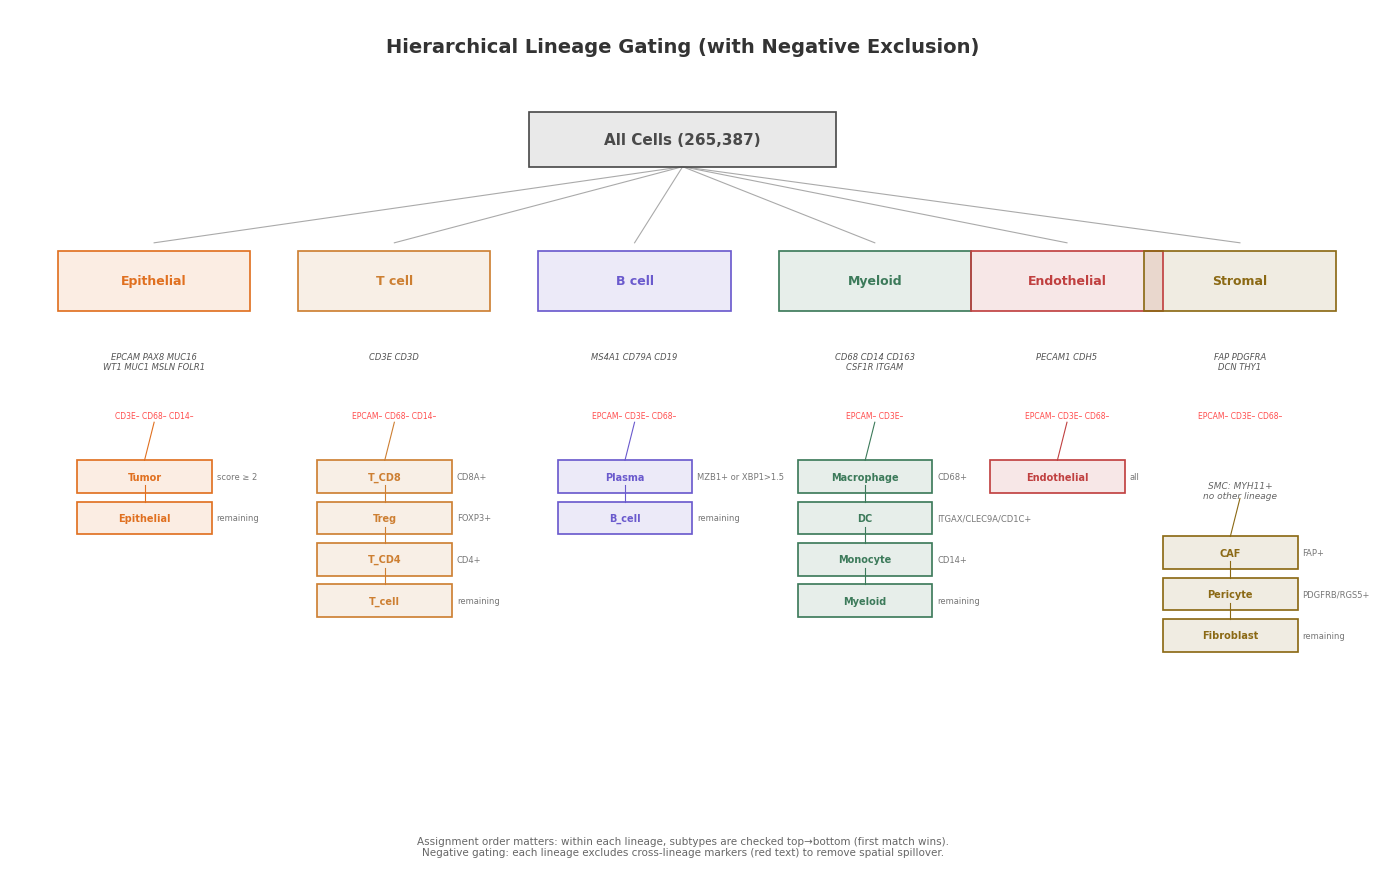

In [6]:
# --- Hierarchical annotation diagram ---
fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xlim(0, 14)
ax.set_ylim(5, 13)
ax.axis('off')

C = {
    'root': '#4a4a4a', 'E': '#e07020', 'T': '#cd7f32', 'B': '#6a5acd',
    'M': '#3c7a5a', 'En': '#c04040', 'S': '#8b6914', 'SM': '#666666',
    'U': '#888888',
}

def box(x, y, w, h, label, color, fontsize=8, bold=False):
    rect = plt.Rectangle((x - w/2, y - h/2), w, h, linewidth=1.2,
                          edgecolor=color, facecolor=color, alpha=0.12, zorder=2)
    ax.add_patch(rect)
    rect2 = plt.Rectangle((x - w/2, y - h/2), w, h, linewidth=1.2,
                           edgecolor=color, facecolor='none', zorder=3)
    ax.add_patch(rect2)
    ax.text(x, y, label, ha='center', va='center', fontsize=fontsize,
            fontweight='bold' if bold else 'normal', color=color, zorder=4)

def conn(x1, y1, x2, y2, color='#aaaaaa', lw=0.8):
    ax.plot([x1, x2], [y1, y2], color=color, lw=lw, zorder=1)

# Title
ax.text(7, 12.6, 'Hierarchical Lineage Gating (with Negative Exclusion)',
        ha='center', fontsize=14, fontweight='bold', color='#333')

# Root
box(7, 11.8, 3.2, 0.5, 'All Cells (265,387)', C['root'], fontsize=11, bold=True)

# Lineage boxes
lineages = [
    (1.5,  'E',  'Epithelial',   'EPCAM PAX8 MUC16\nWT1 MUC1 MSLN FOLR1', 'CD3E\u2013 CD68\u2013 CD14\u2013'),
    (4.0,  'T',  'T cell',       'CD3E CD3D',                                'EPCAM\u2013 CD68\u2013 CD14\u2013'),
    (6.5,  'B',  'B cell',       'MS4A1 CD79A CD19',                         'EPCAM\u2013 CD3E\u2013 CD68\u2013'),
    (9.0,  'M',  'Myeloid',      'CD68 CD14 CD163\nCSF1R ITGAM',            'EPCAM\u2013 CD3E\u2013'),
    (11.0, 'En', 'Endothelial',  'PECAM1 CDH5',                              'EPCAM\u2013 CD3E\u2013 CD68\u2013'),
    (12.8, 'S',  'Stromal',      'FAP PDGFRA\nDCN THY1',                    'EPCAM\u2013 CD3E\u2013 CD68\u2013'),
]

for lx, key, name, markers, excl in lineages:
    conn(7, 11.55, lx, 10.85)
    box(lx, 10.5, 2.0, 0.55, name, C[key], fontsize=9, bold=True)
    ax.text(lx, 9.85, markers, ha='center', va='top', fontsize=6, color='#555', style='italic')
    ax.text(lx, 9.3, excl, ha='center', va='top', fontsize=5.5, color='red', alpha=0.7)

# SMC (separate, strict gating)
ax.text(12.8, 8.5, 'SMC: MYH11+\nno other lineage', ha='center', fontsize=6.5,
        color=C['SM'], style='italic')

# Subtypes
row_h = 0.38

def draw_subtypes(parent_x, start_y, subtypes, color):
    for i, (name, rule) in enumerate(subtypes):
        y = start_y - i * row_h
        box(parent_x - 0.1, y, 1.4, 0.3, name, color, fontsize=7, bold=True)
        ax.text(parent_x + 0.65, y, rule, ha='left', va='center', fontsize=6, color='#777')
        if i == 0:
            conn(parent_x, start_y + 0.5, parent_x - 0.1, y + 0.15, color=color)
        else:
            conn(parent_x - 0.1, y + row_h - 0.08, parent_x - 0.1, y + 0.15, color=color)

draw_subtypes(1.5, 8.7, [
    ('Tumor', 'score \u2265 2'),
    ('Epithelial', 'remaining'),
], C['E'])

draw_subtypes(4.0, 8.7, [
    ('T_CD8', 'CD8A+'),
    ('Treg', 'FOXP3+'),
    ('T_CD4', 'CD4+'),
    ('T_cell', 'remaining'),
], C['T'])

draw_subtypes(6.5, 8.7, [
    ('Plasma', 'MZB1+ or XBP1>1.5'),
    ('B_cell', 'remaining'),
], C['B'])

draw_subtypes(9.0, 8.7, [
    ('Macrophage', 'CD68+'),
    ('DC', 'ITGAX/CLEC9A/CD1C+'),
    ('Monocyte', 'CD14+'),
    ('Myeloid', 'remaining'),
], C['M'])

draw_subtypes(11.0, 8.7, [
    ('Endothelial', 'all'),
], C['En'])

draw_subtypes(12.8, 8.0, [
    ('CAF', 'FAP+'),
    ('Pericyte', 'PDGFRB/RGS5+'),
    ('Fibroblast', 'remaining'),
], C['S'])

# Footer
ax.text(7, 5.3,
    'Assignment order matters: within each lineage, subtypes are checked top\u2192bottom (first match wins).\n'
    'Negative gating: each lineage excludes cross-lineage markers (red text) to remove spatial spillover.',
    ha='center', va='center', fontsize=7.5, color='#666')

plt.tight_layout()
plt.show()

In [7]:
# =============================================================================
# Define exclusion marker sets (for negative gating)
# =============================================================================
EXCL_EPI = ['EPCAM', 'PAX8', 'MUC16']
EXCL_TCELL = ['CD3E', 'CD3D']
EXCL_MYELOID = ['CD68', 'CD14']
EXCL_STROMAL = ['FAP', 'PDGFRA']

def detected(gene):
    return get_expression(adata, gene) > 0

def any_detected(genes):
    result = np.zeros(adata.n_obs, dtype=bool)
    for g in genes:
        result |= detected(g)
    return result

def count_detected(genes):
    result = np.zeros(adata.n_obs)
    for g in genes:
        if g in adata.var_names:
            result += detected(g).astype(float)
    return result

# =============================================================================
# Step 1: Lineage assignment with negative gating
# =============================================================================
print('=== Step 1: Lineage Assignment with Negative Gating ===')

lineage = np.full(adata.n_obs, 'Unassigned', dtype=object)

# Epithelial: EPCAM/PAX8/MUC16/WT1/MUC1/MSLN/FOLR1, exclude CD3E+ CD68+
epi_markers = ['EPCAM', 'PAX8', 'MUC16', 'WT1', 'MUC1', 'MSLN', 'FOLR1']
epi_score = count_detected(epi_markers)
epi_excl = any_detected(EXCL_TCELL) | any_detected(EXCL_MYELOID)
epi_mask = (epi_score >= 1) & ~epi_excl
lineage[epi_mask] = 'Epithelial'
print(f'Epithelial: {epi_mask.sum():,} (score>=1, CD3E- CD68- CD14-)')

# T cell: CD3E/CD3D, exclude EPCAM+ CD68+
tcell_score = count_detected(['CD3E', 'CD3D'])
tcell_excl = any_detected(EXCL_EPI) | any_detected(EXCL_MYELOID)
tcell_mask = (tcell_score >= 1) & ~tcell_excl & (lineage == 'Unassigned')
lineage[tcell_mask] = 'T_cell'
print(f'T cell:     {tcell_mask.sum():,} (CD3E/CD3D+, EPCAM- CD68- CD14-)')

# B cell: MS4A1/CD79A/CD19, exclude EPCAM+ CD3E+ CD68+
bcell_score = count_detected(['MS4A1', 'CD79A', 'CD19'])
bcell_excl = any_detected(EXCL_EPI) | any_detected(EXCL_TCELL) | any_detected(EXCL_MYELOID)
bcell_mask = (bcell_score >= 1) & ~bcell_excl & (lineage == 'Unassigned')
lineage[bcell_mask] = 'B_cell'
print(f'B cell:     {bcell_mask.sum():,} (MS4A1/CD79A/CD19+, EPCAM- CD3E- CD68-)')

# Myeloid: CD68/CD14/CD163/CSF1R/ITGAM, exclude EPCAM+ CD3E+
mye_markers = ['CD68', 'CD14', 'CD163', 'CSF1R', 'ITGAM']
mye_score = count_detected(mye_markers)
mye_excl = any_detected(EXCL_EPI) | any_detected(EXCL_TCELL)
mye_mask = (mye_score >= 1) & ~mye_excl & (lineage == 'Unassigned')
lineage[mye_mask] = 'Myeloid'
print(f'Myeloid:    {mye_mask.sum():,} (CD68/CD14+, EPCAM- CD3E-)')

# Endothelial: PECAM1/CDH5, exclude EPCAM+ CD3E+ CD68+
endo_score = count_detected(['PECAM1', 'CDH5'])
endo_excl = any_detected(EXCL_EPI) | any_detected(EXCL_TCELL) | any_detected(EXCL_MYELOID)
endo_mask = (endo_score >= 1) & ~endo_excl & (lineage == 'Unassigned')
lineage[endo_mask] = 'Endothelial'
print(f'Endothelial:{endo_mask.sum():,} (PECAM1/CDH5+, EPCAM- CD3E- CD68-)')

# Stromal: FAP/PDGFRA/DCN/THY1, exclude EPCAM+ CD3E+ CD68+
str_markers = ['FAP', 'PDGFRA', 'DCN', 'THY1']
str_score = count_detected(str_markers)
str_excl = any_detected(EXCL_EPI) | any_detected(EXCL_TCELL) | any_detected(EXCL_MYELOID)
str_mask = (str_score >= 1) & ~str_excl & (lineage == 'Unassigned')
lineage[str_mask] = 'Stromal'
print(f'Stromal:    {str_mask.sum():,} (FAP/PDGFRA/DCN+, EPCAM- CD3E- CD68-)')

# SMC: MYH11+, exclude ALL other lineage markers (strictest)
smc_excl = (any_detected(EXCL_EPI) | any_detected(EXCL_TCELL) |
            any_detected(EXCL_MYELOID) | any_detected(EXCL_STROMAL) |
            any_detected(['PECAM1', 'CDH5', 'MS4A1', 'CD79A']))
smc_mask = detected('MYH11') & ~smc_excl & (lineage == 'Unassigned')
lineage[smc_mask] = 'SMC'
print(f'SMC:        {smc_mask.sum():,} (MYH11+, no other lineage markers)')

n_unassigned = (lineage == 'Unassigned').sum()
print(f'Unassigned: {n_unassigned:,} ({n_unassigned/adata.n_obs*100:.1f}%)')

=== Step 1: Lineage Assignment with Negative Gating ===


Epithelial: 140,933 (score>=1, CD3E- CD68- CD14-)


T cell:     2,666 (CD3E/CD3D+, EPCAM- CD68- CD14-)


B cell:     969 (MS4A1/CD79A/CD19+, EPCAM- CD3E- CD68-)


Myeloid:    14,809 (CD68/CD14+, EPCAM- CD3E-)


Endothelial:5,000 (PECAM1/CDH5+, EPCAM- CD3E- CD68-)


Stromal:    44,613 (FAP/PDGFRA/DCN+, EPCAM- CD3E- CD68-)


SMC:        5,436 (MYH11+, no other lineage markers)
Unassigned: 50,961 (19.2%)


In [8]:
# =============================================================================
# Step 2: Subtype assignment
# =============================================================================
print('=== Step 2: Subtype Assignment ===')

cell_type = lineage.copy()

# --- Epithelial -> Tumor vs Epithelial ---
epi = lineage == 'Epithelial'
tumor_score = count_detected(['PAX8', 'WT1', 'MUC16', 'MKI67', 'MSLN', 'FOLR1'])
tumor = epi & (tumor_score >= 2)
cell_type[tumor] = 'Tumor'
cell_type[epi & ~tumor] = 'Epithelial'
print(f'Tumor:      {tumor.sum():,}')
print(f'Epithelial: {(epi & ~tumor).sum():,}')

# --- T cell subtypes ---
t = lineage == 'T_cell'
cd8 = t & detected('CD8A')
cell_type[cd8] = 'T_CD8'
treg = t & ~cd8 & detected('FOXP3')
cell_type[treg] = 'Treg'
cd4 = t & ~cd8 & ~treg & detected('CD4')
cell_type[cd4] = 'T_CD4'
t_other = t & ~cd8 & ~treg & ~cd4
cell_type[t_other] = 'T_cell'
print(f'T_CD8: {cd8.sum():,}, Treg: {treg.sum():,}, T_CD4: {cd4.sum():,}, T_cell: {t_other.sum():,}')

# --- B cell subtypes ---
b = lineage == 'B_cell'
plasma = b & (detected('MZB1') | (get_expression(adata, 'XBP1') > 1.5))
cell_type[plasma] = 'Plasma'
cell_type[b & ~plasma] = 'B_cell'
print(f'Plasma: {plasma.sum():,}, B_cell: {(b & ~plasma).sum():,}')

# --- Myeloid subtypes (CD68 before CD14) ---
mye = lineage == 'Myeloid'
mac = mye & detected('CD68')
cell_type[mac] = 'Macrophage'
dc = mye & ~mac & (detected('ITGAX') | detected('CLEC9A') | detected('CD1C'))
cell_type[dc] = 'DC'
mono = mye & ~mac & ~dc & detected('CD14')
cell_type[mono] = 'Monocyte'
mye_other = mye & ~mac & ~dc & ~mono
cell_type[mye_other] = 'Myeloid'
print(f'Macrophage: {mac.sum():,}, DC: {dc.sum():,}, Monocyte: {mono.sum():,}, Myeloid: {mye_other.sum():,}')

# --- Stromal subtypes ---
s = lineage == 'Stromal'
caf = s & detected('FAP')
cell_type[caf] = 'CAF'
peri = s & ~caf & (detected('PDGFRB') | detected('RGS5'))
cell_type[peri] = 'Pericyte'
fib = s & ~caf & ~peri
cell_type[fib] = 'Fibroblast'
print(f'CAF: {caf.sum():,}, Pericyte: {peri.sum():,}, Fibroblast: {fib.sum():,}')

# --- Endothelial, SMC stay as-is ---
print(f'Endothelial: {(lineage == "Endothelial").sum():,}')
print(f'SMC: {smc_mask.sum():,}')

adata.obs['cell_type'] = cell_type

=== Step 2: Subtype Assignment ===


Tumor:      48,653
Epithelial: 92,280


T_CD8: 802, Treg: 43, T_CD4: 118, T_cell: 1,703
Plasma: 182, B_cell: 787


Macrophage: 5,099, DC: 651, Monocyte: 5,524, Myeloid: 3,535


CAF: 9,267, Pericyte: 7,075, Fibroblast: 28,271
Endothelial: 5,000
SMC: 5,436


In [9]:
# Final distribution
ct = adata.obs['cell_type']
ct_counts = ct.value_counts()
n_assigned = (ct != 'Unassigned').sum()
n_types = len([t for t in ct_counts.index if t != 'Unassigned'])

print(f'Cell types: {n_types}')
print(f'Assigned: {n_assigned:,} ({100*n_assigned/adata.n_obs:.1f}%)')
print(f'Unassigned: {adata.n_obs - n_assigned:,} ({100*(adata.n_obs - n_assigned)/adata.n_obs:.1f}%)')

print(f'\n{"Cell Type":<20s} {"Count":>10s} {"% Total":>10s}')
print('-' * 42)
for name, n in ct_counts.items():
    print(f'{name:<20s} {n:>10,} {100*n/adata.n_obs:>9.1f}%')

Cell types: 17
Assigned: 214,426 (80.8%)
Unassigned: 50,961 (19.2%)

Cell Type                 Count    % Total
------------------------------------------
Epithelial               92,280      34.8%
Unassigned               50,961      19.2%
Tumor                    48,653      18.3%
Fibroblast               28,271      10.7%
CAF                       9,267       3.5%
Pericyte                  7,075       2.7%
Monocyte                  5,524       2.1%
SMC                       5,436       2.0%
Macrophage                5,099       1.9%
Endothelial               5,000       1.9%
Myeloid                   3,535       1.3%
T_cell                    1,703       0.6%
T_CD8                       802       0.3%
B_cell                      787       0.3%
DC                          651       0.2%
Plasma                      182       0.1%
T_CD4                       118       0.0%
Treg                         43       0.0%


In [10]:
# =============================================================================
# Cross-contamination check (should be ~0%)
# =============================================================================
print('=== Cross-contamination Check ===')

lineage_check = {
    'Epithelial': EXCL_EPI, 'T cell': EXCL_TCELL,
    'Myeloid': EXCL_MYELOID, 'Stromal': ['FAP', 'PDGFRA', 'DCN'],
}

expected_lineage = {
    'Tumor': ['Epithelial'], 'Epithelial': ['Epithelial'],
    'T_CD8': ['T cell'], 'T_cell': ['T cell'], 'T_CD4': ['T cell'], 'Treg': ['T cell'],
    'Macrophage': ['Myeloid'], 'Monocyte': ['Myeloid'], 'DC': ['Myeloid'],
    'CAF': ['Stromal'], 'Fibroblast': ['Stromal'], 'Pericyte': ['Stromal'],
}

for ctype in ['Tumor', 'Epithelial', 'T_CD8', 'T_cell', 'Macrophage', 'Monocyte',
              'CAF', 'Fibroblast', 'Endothelial', 'SMC', 'B_cell']:
    mask = cell_type == ctype
    if mask.sum() < 10:
        continue
    contam = []
    for lin, genes in lineage_check.items():
        any_expr = np.zeros(mask.sum(), dtype=bool)
        for g in genes:
            if g in adata.var_names:
                any_expr |= (adata[mask, g].X.toarray().flatten() > 0)
        pct = any_expr.mean() * 100
        if lin not in expected_lineage.get(ctype, []) and pct > 1:
            contam.append(f'{lin}={pct:.1f}%')
    if contam:
        print(f'  {ctype:15s}: {" ".join(contam)}')
    else:
        print(f'  {ctype:15s}: clean')

=== Cross-contamination Check ===


  Tumor          : Stromal=8.9%


  Epithelial     : Stromal=11.2%
  T_CD8          : Stromal=31.9%
  T_cell         : Stromal=40.6%
  Macrophage     : Stromal=33.6%


  Monocyte       : Stromal=35.0%
  CAF            : clean


  Fibroblast     : clean
  Endothelial    : Stromal=27.6%
  SMC            : clean
  B_cell         : Stromal=35.7%


---
## 4. Spatial Compartment Definition

Define three tissue compartments based on the spatial distribution of epithelial cells:

1. **Rasterize** cell positions onto a 10 µm grid
2. **Compute epithelial fraction** = (Tumor + Epithelial cells) / (all cells) per grid pixel
3. **Gaussian smooth** with σ = 50 µm (5 grid pixels) to get local epithelial density
4. **Threshold** at 0.5 → binary tumor region mask
5. **Signed EDT** — negative inside tumor, positive outside
6. **Assign compartments** by signed distance:
   - **Tumor**: distance ≤ 0 µm (inside tumor region)
   - **Interface**: 0 < distance ≤ 50 µm (50 µm buffer)
   - **Stroma**: distance > 50 µm

In [11]:
# =============================================================================
# Compartment definition via epithelial density + signed EDT
# =============================================================================
x = adata.obs['x_centroid'].values
y = adata.obs['y_centroid'].values
is_epi = (cell_type == 'Tumor') | (cell_type == 'Epithelial')

print(f'Epithelial cells (Tumor + Epithelial): {is_epi.sum():,} / {adata.n_obs:,} '
      f'({is_epi.mean()*100:.1f}%)')

# Step 1: Rasterize onto spatial grid
gx = (x / GRID_SIZE).astype(int)
gy = (y / GRID_SIZE).astype(int)
grid_shape = (gy.max() + 2, gx.max() + 2)

epi_grid = np.zeros(grid_shape)
np.add.at(epi_grid, (gy[is_epi], gx[is_epi]), 1)

total_grid = np.zeros(grid_shape)
np.add.at(total_grid, (gy, gx), 1)

# Step 2: Smoothed epithelial fraction
epi_smooth = gaussian_filter(epi_grid.astype(float), sigma=SIGMA)
total_smooth = gaussian_filter(total_grid.astype(float), sigma=SIGMA)
epi_frac = np.divide(epi_smooth, total_smooth,
                     where=total_smooth > 0,
                     out=np.zeros_like(epi_smooth))

# Step 3: Tumor region mask (no hole-filling — preserves stromal channels within tumor)
tumor_mask = epi_frac > EPI_THRESHOLD

# Step 4: Signed EDT
dist_inside = distance_transform_edt(tumor_mask) * GRID_SIZE
dist_outside = distance_transform_edt(~tumor_mask) * GRID_SIZE
signed_dist_grid = dist_outside - dist_inside  # negative = inside tumor

# Per-cell signed distance
cell_dist = signed_dist_grid[gy, gx]

# Step 5: Assign compartments
compartment = np.full(adata.n_obs, '', dtype=object)
compartment[cell_dist <= 0] = 'Tumor'
compartment[(cell_dist > 0) & (cell_dist <= INTERFACE_WIDTH)] = 'Interface'
compartment[cell_dist > INTERFACE_WIDTH] = 'Stroma'

adata.obs['compartment'] = compartment
adata.obs['compartment_dist'] = cell_dist

# Summary
print(f'\nCompartments:')
for c in ['Tumor', 'Interface', 'Stroma']:
    n = (compartment == c).sum()
    print(f'  {c:<12}: {n:>7,} ({n/adata.n_obs*100:.1f}%)')

# Tumor capture check
tumor_cells = cell_type == 'Tumor'
tumor_in_tumor_comp = tumor_cells & (compartment == 'Tumor')
print(f'\nTumor capture: {tumor_in_tumor_comp.sum():,} / {tumor_cells.sum():,} '
      f'({tumor_in_tumor_comp.sum()/tumor_cells.sum()*100:.1f}%) of tumor cells in Tumor compartment')

Epithelial cells (Tumor + Epithelial): 140,933 / 265,387 (53.1%)



Compartments:
  Tumor       : 183,517 (69.2%)
  Interface   :  30,437 (11.5%)
  Stroma      :  51,433 (19.4%)

Tumor capture: 45,396 / 48,653 (93.3%) of tumor cells in Tumor compartment


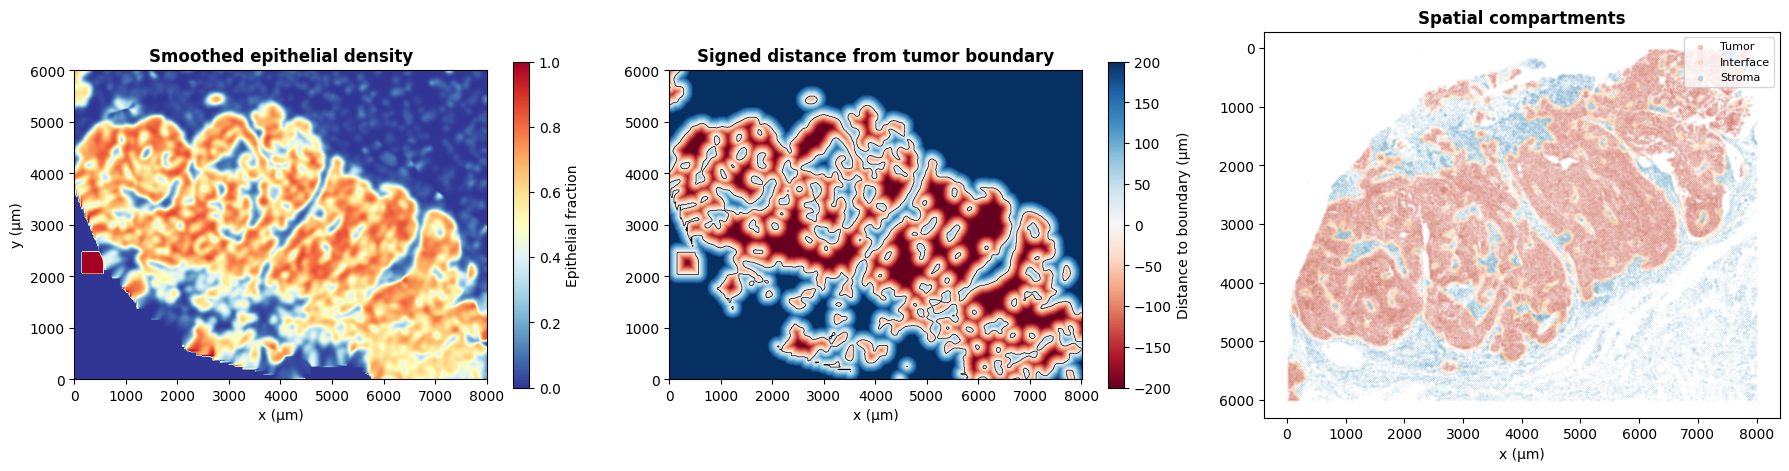

In [12]:
# --- Compartment visualization ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Epithelial fraction heatmap
ax = axes[0]
im = ax.imshow(epi_frac, cmap='RdYlBu_r', vmin=0, vmax=1, origin='lower',
               extent=[0, grid_shape[1]*GRID_SIZE, 0, grid_shape[0]*GRID_SIZE])
plt.colorbar(im, ax=ax, label='Epithelial fraction', shrink=0.7)
ax.set_title('Smoothed epithelial density', fontweight='bold')
ax.set_xlabel('x (\u00b5m)')
ax.set_ylabel('y (\u00b5m)')

# Panel 2: Signed distance
ax = axes[1]
im2 = ax.imshow(signed_dist_grid, cmap='RdBu', vmin=-200, vmax=200, origin='lower',
                extent=[0, grid_shape[1]*GRID_SIZE, 0, grid_shape[0]*GRID_SIZE])
plt.colorbar(im2, ax=ax, label='Distance to boundary (\u00b5m)', shrink=0.7)
ax.contour(tumor_mask, levels=[0.5], colors='k', linewidths=0.5, origin='lower',
           extent=[0, grid_shape[1]*GRID_SIZE, 0, grid_shape[0]*GRID_SIZE])
ax.set_title('Signed distance from tumor boundary', fontweight='bold')
ax.set_xlabel('x (\u00b5m)')

# Panel 3: Compartment map
ax = axes[2]
comp_colors = {'Tumor': '#d6604d', 'Interface': '#fdb863', 'Stroma': '#4393c3'}
for comp, color in comp_colors.items():
    mask = compartment == comp
    ax.scatter(x[mask], y[mask], s=0.01, alpha=0.3, c=color, rasterized=True, label=comp)
ax.set_title('Spatial compartments', fontweight='bold')
ax.set_xlabel('x (\u00b5m)')
ax.set_aspect('equal')
ax.invert_yaxis()
ax.legend(markerscale=30, loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

---
## 5. Validation

### Marker dot plot
Each cell type should express its canonical positive markers and lack negative markers.

### Proportions and spatial co-localization
Verify cell type distribution matches expected biology for high-grade serous ovarian cancer.

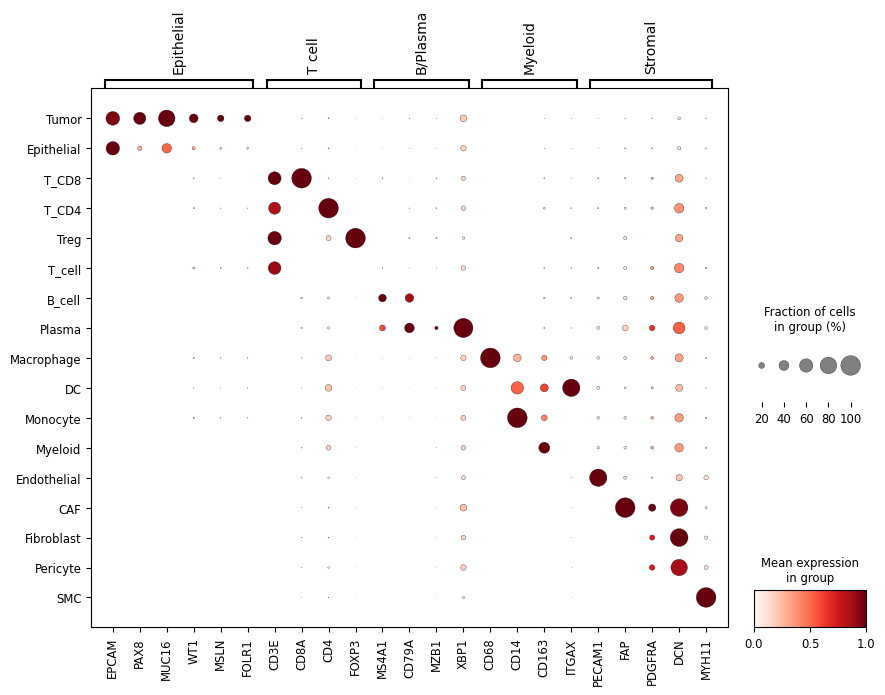

In [13]:
# --- Marker dot plot ---
CT_ORDER = [
    'Tumor', 'Epithelial',
    'T_CD8', 'T_CD4', 'Treg', 'T_cell',
    'B_cell', 'Plasma',
    'Macrophage', 'DC', 'Monocyte', 'Myeloid',
    'Endothelial',
    'CAF', 'Fibroblast', 'Pericyte',
    'SMC',
]

ct_present = [t for t in CT_ORDER if (adata.obs['cell_type'] == t).sum() > 0]

DOTPLOT_MARKERS = {
    'Epithelial': ['EPCAM', 'PAX8', 'MUC16', 'WT1', 'MSLN', 'FOLR1'],
    'T cell': ['CD3E', 'CD8A', 'CD4', 'FOXP3'],
    'B/Plasma': ['MS4A1', 'CD79A', 'MZB1', 'XBP1'],
    'Myeloid': ['CD68', 'CD14', 'CD163', 'ITGAX'],
    'Stromal': ['PECAM1', 'FAP', 'PDGFRA', 'DCN', 'MYH11'],
}

dotplot_markers = {}
for group, genes in DOTPLOT_MARKERS.items():
    avail = [g for g in genes if g in adata.var_names]
    if avail:
        dotplot_markers[group] = avail

adata_plot = adata[adata.obs['cell_type'].isin(ct_present)].copy()

sc.pl.dotplot(adata_plot, var_names=dotplot_markers, groupby='cell_type',
              categories_order=ct_present, standard_scale='var',
              dendrogram=False, figsize=(10, 7), show=True)

del adata_plot

In [14]:
# --- Cell type proportions per compartment ---
ct = adata.obs['cell_type']
comp = adata.obs['compartment']

print('Cell type distribution per compartment:')
print(f'\n{"Cell Type":<15s} {"Tumor":>10s} {"Interface":>10s} {"Stroma":>10s} {"Total":>10s}')
print('-' * 60)

for ctype in CT_ORDER:
    mask = ct == ctype
    if mask.sum() == 0:
        continue
    vals = []
    for c in ['Tumor', 'Interface', 'Stroma']:
        n = (mask & (comp == c)).sum()
        vals.append(f'{n:,}')
    print(f'{ctype:<15s} {vals[0]:>10s} {vals[1]:>10s} {vals[2]:>10s} {mask.sum():>10,}')

# Key biology: immune exclusion
print('\n--- Immune compartment distribution ---')
for ctype in ['T_CD8', 'Macrophage', 'CAF', 'Fibroblast']:
    mask = ct == ctype
    if mask.sum() == 0:
        continue
    fracs = []
    for c in ['Tumor', 'Interface', 'Stroma']:
        f = (mask & (comp == c)).sum() / mask.sum() * 100
        fracs.append(f'{f:.1f}%')
    print(f'  {ctype:<15s}: Tumor {fracs[0]:>6s}, Interface {fracs[1]:>6s}, Stroma {fracs[2]:>6s}')

Cell type distribution per compartment:

Cell Type            Tumor  Interface     Stroma      Total
------------------------------------------------------------
Tumor               45,396      2,158      1,099     48,653
Epithelial          80,738      6,561      4,981     92,280
T_CD8                  217        160        425        802


T_CD4                   31         25         62        118
Treg                    17          5         21         43
T_cell                 630        326        747      1,703
B_cell                 345        143        299        787


Plasma                  75         39         68        182
Macrophage           2,450        962      1,687      5,099
DC                     307        128        216        651
Monocyte             2,047        998      2,479      5,524


Myeloid              1,276        672      1,587      3,535
Endothelial            949        944      3,107      5,000
CAF                  3,848      2,707      2,712      9,267
Fibroblast           8,420      6,287     13,564     28,271


Pericyte             2,026      1,906      3,143      7,075
SMC                    270        303      4,863      5,436

--- Immune compartment distribution ---
  T_CD8          : Tumor  27.1%, Interface  20.0%, Stroma  53.0%
  Macrophage     : Tumor  48.0%, Interface  18.9%, Stroma  33.1%


  CAF            : Tumor  41.5%, Interface  29.2%, Stroma  29.3%
  Fibroblast     : Tumor  29.8%, Interface  22.2%, Stroma  48.0%


In [15]:
# --- Spatial co-localization ---
print('Spatial co-localization (k=15 neighbors):')
coords = adata.obsm['spatial']
tree = cKDTree(coords)
_, sp_idx = tree.query(coords, k=16)
sp_idx = sp_idx[:, 1:]  # exclude self

ct_arr = ct.values
COLOC = {
    ('Tumor', 'CAF'):          'Tumor-stroma interface',
    ('T_CD8', 'CAF'):          'Immune exclusion barrier',
    ('T_CD8', 'Fibroblast'):   'Immune exclusion barrier',
    ('Macrophage', 'Tumor'):   'TAM infiltration',
    ('Endothelial', 'Pericyte'): 'Vasculature',
    ('T_CD8', 'Tumor'):        'T cell infiltration',
}

print(f'\n{"CT1":<15s} {"CT2":<15s} {"Enrichment":>12s} {"Biology":>25s}')
print('-' * 72)
for (ct1, ct2), biology in COLOC.items():
    m1 = ct_arr == ct1
    if m1.sum() == 0:
        continue
    expected = (ct_arr == ct2).sum() / len(ct_arr)
    observed = (ct_arr[sp_idx[m1].flatten()] == ct2).mean()
    enr = observed / expected if expected > 0 else 0
    print(f'{ct1:<15s} {ct2:<15s} {enr:>10.2f}x  {biology:>25s}')

Spatial co-localization (k=15 neighbors):



CT1             CT2               Enrichment                   Biology
------------------------------------------------------------------------
Tumor           CAF                   0.32x     Tumor-stroma interface
T_CD8           CAF                   1.77x   Immune exclusion barrier
T_CD8           Fibroblast            1.89x   Immune exclusion barrier
Macrophage      Tumor                 0.58x           TAM infiltration
Endothelial     Pericyte              3.65x                Vasculature
T_CD8           Tumor                 0.32x        T cell infiltration


---
## 6. Save

Save annotated h5ad with `cell_type` and `compartment` columns, ready for CONSTELLATION analysis.

In [16]:
# Save
adata.write_h5ad(OUTPUT_PATH)

ct_counts = adata.obs['cell_type'].value_counts()
n_types = len([t for t in ct_counts.index if t != 'Unassigned'])
n_assigned = (adata.obs['cell_type'] != 'Unassigned').sum()

print(f'Saved: {OUTPUT_PATH}')
print(f'Shape: {adata.shape}')
print(f'Cell types: {n_types}')
print(f'Assigned: {n_assigned:,} ({100*n_assigned/adata.n_obs:.1f}%)')
print(f'Compartments: {adata.obs["compartment"].value_counts().to_dict()}')

Saved: data/xenium_oc_annotated.h5ad
Shape: (265387, 5101)
Cell types: 17
Assigned: 214,426 (80.8%)
Compartments: {'Tumor': 183517, 'Stroma': 51433, 'Interface': 30437}
